STEP 1: Import Required Libraries

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
import ssl

STEP 2: Load Image from Google Drive (grayscale)

In [2]:
# Convert share link to direct download link
image_url = "https://drive.google.com/uc?export=download&id=1kWIx5TR65nuAIThAUgcn31ccBsOgVQW-"

# Load image from the URL
context = ssl._create_unverified_context()
resp = urllib.request.urlopen(image_url, context=context)
image_bytes = np.asarray(bytearray(resp.read()), dtype=np.uint8)
gray = cv2.imdecode(image_bytes, cv2.IMREAD_GRAYSCALE)

if gray is None:
    raise Exception("❌ Image could not be loaded.")
else:
    print("✅ Image loaded successfully.")

✅ Image loaded successfully.


STEP 3: Define Gradient Filters - Prewitt and Sobel

    🔍 Definition:
        # Image gradient measures the intensity change at each pixel.
        # It highlights edges (boundaries) in horizontal and vertical directions.

    🔍 Formulas:
        # Gx = horizontal gradient = dI/dx
        # Gy = vertical gradient = dI/dy
        # Resultant Gradient Magnitude = sqrt(Gx² + Gy²)

In [3]:
# Prewitt Kernels
prewitt_x = np.array([[ -1,  0,  1],
                      [ -1,  0,  1],
                      [ -1,  0,  1]])
prewitt_y = np.array([[  1,  1,  1],
                      [  0,  0,  0],
                      [ -1, -1, -1]])
# STEP 4: Apply Prewitt Operator (Manual)
# -------------------------------------------------------------
prewitt_horizontal = cv2.filter2D(gray, -1, prewitt_x)
prewitt_vertical = cv2.filter2D(gray, -1, prewitt_y)
prewitt_resultant = cv2.magnitude(prewitt_horizontal.astype(np.float32),
                                  prewitt_vertical.astype(np.float32))

STEP 5: Apply Sobel Operator (OpenCV)

In [4]:
sobel_horizontal = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
sobel_vertical   = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
sobel_resultant  = cv2.magnitude(sobel_horizontal, sobel_vertical)

# Normalize for display
prewitt_resultant = cv2.normalize(prewitt_resultant, None, 0, 255, cv2.NORM_MINMAX)
sobel_resultant   = cv2.normalize(sobel_resultant, None, 0, 255, cv2.NORM_MINMAX)

STEP 6: Apply Canny Edge Detection


    🔍 Canny is a multi-stage detector:
        1. Gaussian smoothing
        2. Compute gradient magnitude and direction
        3. Non-maximum suppression
        4. Double threshold and edge tracking by hysteresis
          ▪ Low threshold: weak edges
          ▪ High threshold: strong edges

In [5]:
canny_edges = cv2.Canny(gray, threshold1=100, threshold2=200)

STEP 7: Display Results

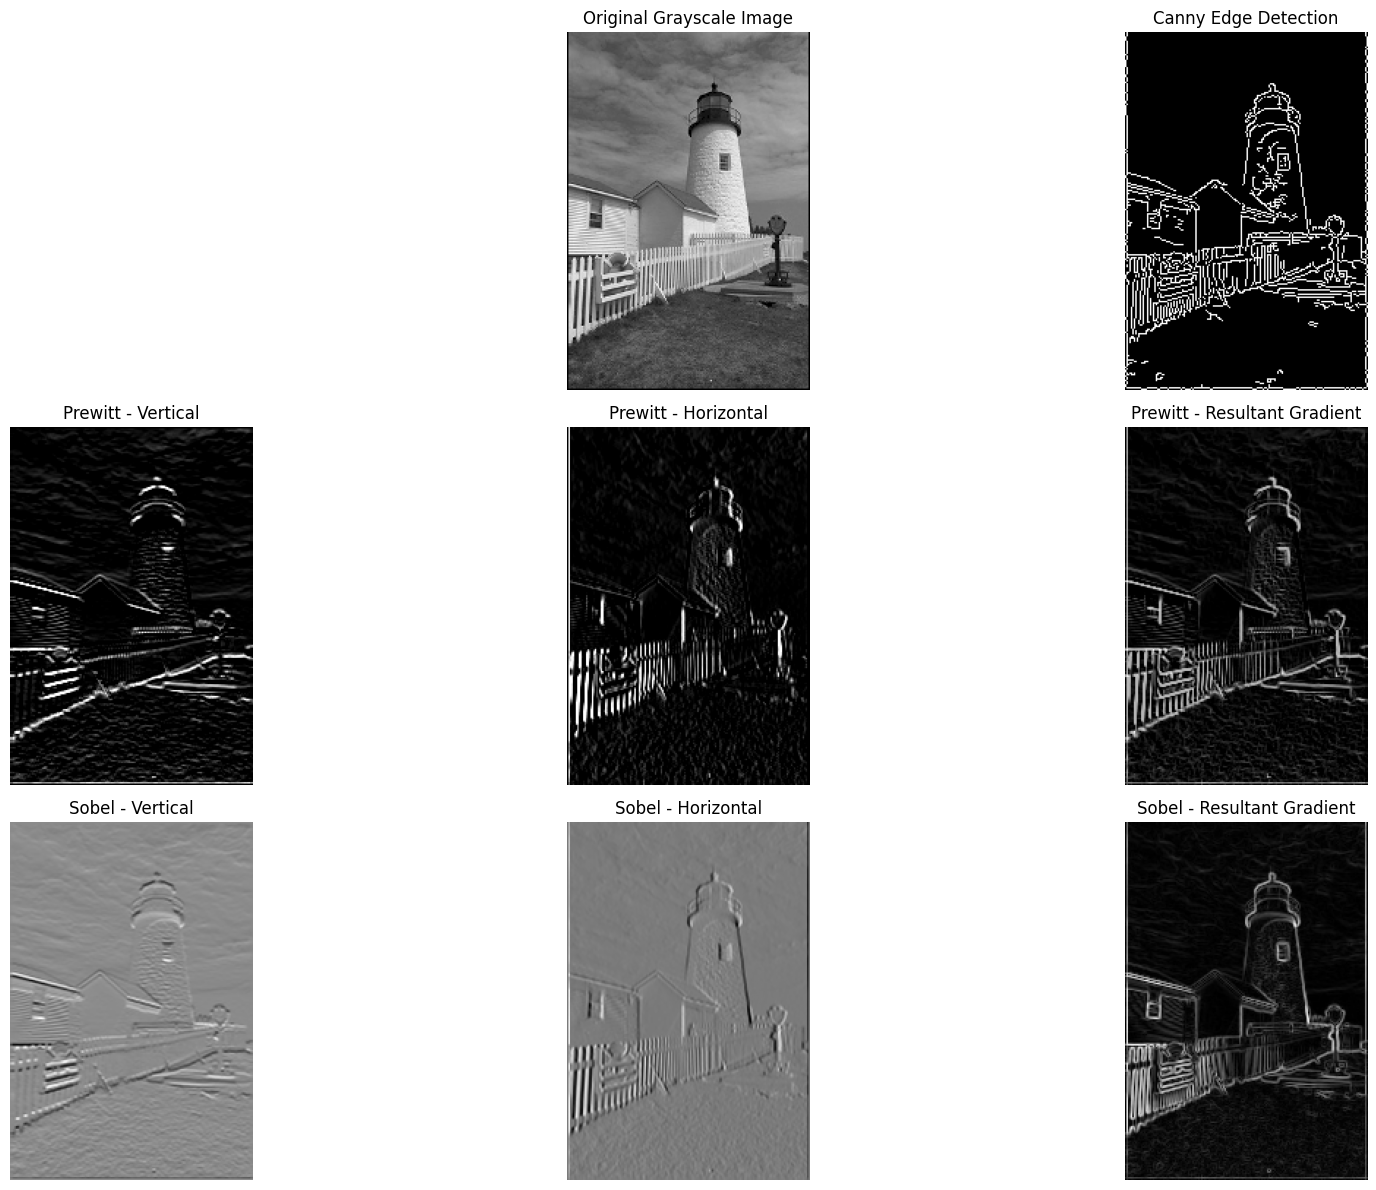

In [6]:
plt.figure(figsize=(18, 12))

plt.subplot(3, 3, 2)
plt.imshow(gray, cmap='gray')
plt.title("Original Grayscale Image")
plt.axis('off')

# Prewitt
plt.subplot(3, 3, 4)
plt.imshow(prewitt_vertical, cmap='gray')
plt.title("Prewitt - Vertical")
plt.axis('off')

plt.subplot(3, 3, 5)
plt.imshow(prewitt_horizontal, cmap='gray')
plt.title("Prewitt - Horizontal")
plt.axis('off')

plt.subplot(3, 3, 6)
plt.imshow(prewitt_resultant, cmap='gray')
plt.title("Prewitt - Resultant Gradient")
plt.axis('off')

# Sobel
plt.subplot(3, 3, 7)
plt.imshow(sobel_vertical, cmap='gray')
plt.title("Sobel - Vertical")
plt.axis('off')

plt.subplot(3, 3, 8)
plt.imshow(sobel_horizontal, cmap='gray')
plt.title("Sobel - Horizontal")
plt.axis('off')

plt.subplot(3, 3, 9)
plt.imshow(sobel_resultant, cmap='gray')
plt.title("Sobel - Resultant Gradient")
plt.axis('off')

# Canny Edge
plt.subplot(3, 3, 3)
plt.imshow(canny_edges, cmap='gray')
plt.title("Canny Edge Detection")
plt.axis('off')

plt.tight_layout()
plt.show()